In [27]:
# import the necessary packages
import os
import sys
sys.path.append('../src')

# data handling
import numpy as np
import pandas as pd
# Geometry package
from   skgeom import *
from   skgeom.draw import draw
import matplotlib.pyplot as plt
## NN computing
import torch 
# our data
from   data_types import VisSample 
# types
from   typing   import Tuple
# evaluation
from  demo import show, polygon_demo3
from  evaluate import sample_coverage

# regex
import re

# graphics
import matplotlib.pyplot as plt
import seaborn as sns


# availiable device
use_cuda = torch.cuda.is_available()
# BEGIN: List CUDA devices
if use_cuda:
    print("CUDA devices available:")
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
else:
    print("No CUDA devices available.")
# END: List CUDA devices

CUDA devices available:
Device 0: NVIDIA GeForce RTX 3090
Device 1: NVIDIA GeForce RTX 3090


# Supervised Art Gallery Solver

In [35]:
# evaluation interface
class Evaluator:
    def __init__(self, solver, dataset_dir, evaluate = polygon_demo3):
        self.solver = solver
        self.dataset_dir = dataset_dir
        self.evaluate = evaluate
        self.results = {}

    def evaluate_metrics(self, sample):
        """
        Evaluate metrics on test dataset
        """
        key, data = sample['name'], sample['data']
        n = len(sample['data'])
        _coverages, _ratios = np.zeros(n), np.zeros(n)

        for i, instance in enumerate(data):
            # read sample
            print(f'Processing {instance}                         ', end='\r')
            _instance = os.path.join(self.dataset_dir, instance)
            sample = VisSample.read_samples(path=_instance, sol_sample=1)[0]

            # prediction        
            solution = self.solver.predict(_instance, beam_width=4)

            # compute opt and coverage
            _, _, _, opt, coverage = self.evaluate(sample, solution)
            # accumulate
            _coverages[i] = coverage
            _ratios[i] = len(solution) / len(opt)

        self.results[key] = {
            'counts': len(_coverages),
            'mean coverage': np.mean(_coverages),
            'std coverage': np.std(_coverages),
            'mean ratio': np.mean(_ratios),
            'std ratio': np.std(_ratios)
        }

        return self.results

    def stats(self, testbed):
        """
        Run evaluation on testbed
        """
        # list files
        df = pd.DataFrame([file for file in os.listdir(self.dataset_dir) if file.endswith('.pol')], columns=['name'])

        # check patterns
        for i, re in enumerate(testbed['regex']):
            print(f"\nPattern {i + 1}/{len(testbed['regex'])}:")

            # read data using regex
            data = df[df.name.str.match(re)].values.squeeze().tolist()

            # define rows
            sample = {'name': re, 'data': data}

            # evaluate metrics
            self.results = self.evaluate_metrics(sample)

        # show as dataframe
        report = pd.DataFrame.from_dict(self.results, orient='index')
        report.to_json(f"../results/{testbed['name']}.json")        

        display(report)
        
        return report

    def boxplot(self, testbed):
        """
        Run evaluation and generate boxplot
        """
        # list all instances
        files = [file for file in os.listdir(self.dataset_dir) if file.endswith('.pol')]
        # create df for results
        data = pd.DataFrame(columns=['name', 'type', 'coverage', 'ratio'])
        # filter out files via regex
        for regex in testbed['regex']:
            p = re.compile(regex)
            for file in files:
                if p.match(file):  # if file matches regex
                    batch = {'name': regex, 'data': [file]}  # wrap data to use API
                    results = self.evaluate_metrics(batch)
                    cov, r = results[regex]['mean coverage'], results[regex]['mean ratio']  # read mean for singletons
                    data.loc[len(data)] = [file, regex, cov, r]  # set instance name, type, coverage and ratio

        # Determine unique values in the 'type' column
        unique_types = data['type'].unique()
        labels = unique_types.tolist()  # Convert unique types to a list
        colors = sns.color_palette("husl", len(labels))  # Generate a color palette with enough colors

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        # Plot the first boxplot with different colors
        sns.boxplot(ax=axes[0], data=data, x="type", y="coverage", hue="type", palette=colors, legend=False)
        axes[0].set_xticks(range(len(labels)))
        axes[0].set_xticklabels(labels)

        # Plot the second boxplot with different colors
        sns.boxplot(ax=axes[1], data=data, x="type", y="ratio", hue="type", palette=colors, legend=False)
        axes[1].set_xticks(range(len(labels)))
        axes[1].set_xticklabels(labels)

        plt.tight_layout()
        plt.show()

        return data



## Dataset description 

Our dataset consists of AGPIL instances obtained from [AGPPROJ - Art Gallery Problem Project](https://www.ic.unicamp.br/~cid/Problem-instances/Art-Gallery/)

In [29]:
dataset_dir = '../dataset/AG/development/'
samples = {s : [f for f in os.listdir(dataset_dir+s) if f.endswith('.pol')] for s in ['train','dev','test']}
df = pd.DataFrame.from_dict(samples, orient='index').transpose()

# Add a row with the total count per column
df.loc['Total # Instances'] = df.count()

# Display the dataframe
df

,train,dev,test
0,rand-150-27.pol,rand-150-27.pol,rand-350-27.pol
1,rand-130-14.pol,simple-100-5.pol,rand-112-90.pol
2,rand-76-53.pol,rand-152-87.pol,rand-170-48.pol
3,rand-196-156.pol,rand-170-12.pol,rand-176-117.pol
4,rand-170-12.pol,rand-116-79.pol,randvon-70-16.pol
...,...,...,...
8863,rand-136-99.pol,None,None
8864,rand-120-78.pol,None,None
8865,rand-22-8.pol,None,None
8866,randvon-70-2.pol,None,None


Instances are provided as files, represented as `skgeom.polygon` with discretization points.

In [30]:
# test  instance
instance = '../dataset/AG/default/agp2009a-simplerand/20/randsimple-20-1.pol'
sample = VisSample.read_samples(path=instance, sol_sample=1)[0]

sample

VisSample(name='randsimple-20-1', points=[tensor([0.3339, 0.2431, 0.0000]), tensor([0.4086, 0.1993, 0.0000]), tensor([0.3123, 0.1947, 0.0000]), tensor([0.0294, 0.2914, 0.0000]), tensor([0.5614, 0.0000, 0.0000]), tensor([0.5588, 0.0300, 0.0000]), tensor([0.6487, 0.1518, 0.0000]), tensor([0.9293, 0.2615, 0.0000]), tensor([0.9011, 0.4047, 0.0000]), tensor([0.4991, 0.4086, 0.0000]), tensor([0.3483, 0.5342, 0.0000]), tensor([1.0000, 0.5280, 0.0000]), tensor([0.7298, 0.5694, 0.0000]), tensor([0.1837, 0.5815, 0.0000]), tensor([0.3851, 0.3952, 0.0000]), tensor([0.7824, 0.3206, 0.0000]), tensor([0.5420, 0.1363, 0.0000]), tensor([0.3497, 0.3279, 0.0000]), tensor([0.3101, 0.3471, 0.0000]), tensor([0.0000, 0.4646, 0.0000])], guards=tensor([ 5, 13, 15, 19]))

## Pointer Network Approach

In this section, a Pointer Network is trained from labaled AGPIL dataset and used to generate a solution to an instance.


In [36]:
from evaluate import AGNetSearch, Opt

# load model
m1  = '../models/ag_clusters_numsols-1_ne-100_bs-64_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized.pt' 

#opt value
opt_solver = Opt()

# PTrNet search
agnet_solver  = AGNetSearch(m1)

Model loaded successfully.


/mnt/nvme0n1/home/dseverdi/Radno/MLAG/code/AGNet/notebooks/../src/evaluate.py:125: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model = torch.load(model)


### Evaluation

#### Example


 * bidirectional LSTM  
 * 1 solution per instance
 * TGNet pretrained

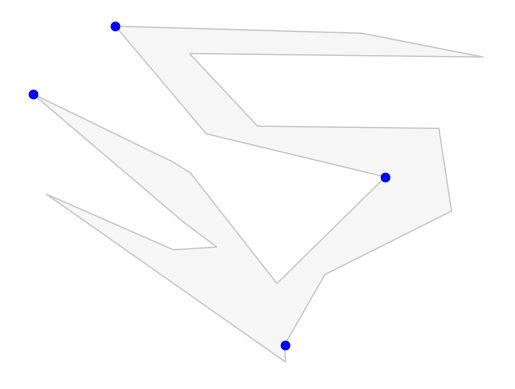

 * Optimal solution size:     4


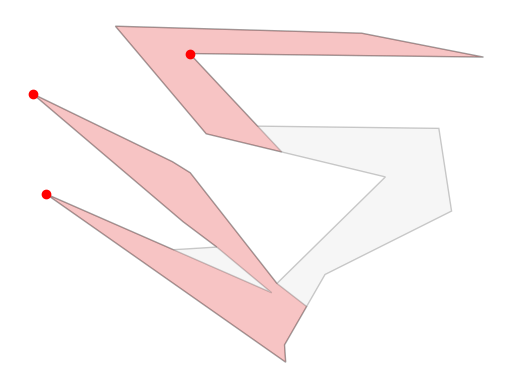

 * Predicted solution size:     3
 * PtrMNet coverage:     0.63179888,      ratio=pred/opt: 0.75000000


In [37]:
# optimal and neural solver
sol_opt    = opt_solver.predict(instance)
sol_agnet  = agnet_solver.predict(instance,beam_width=4)

# show only opt solution
poly, region, predicted, opt, coverage = polygon_demo3(sample,sol_opt)
show(poly, region, None, opt, coverage)

# show all possible predicted solutions
poly, region, predicted, opt, coverage = polygon_demo3(sample,sol_agnet)
show(poly, region, predicted, opt, coverage)

#### Testbeds

In [39]:
results = {}
dataset_dir = '../dataset/AG/development/test'


testbeds = [{ 
    'name' : 'AGNet_testbed_1', 
    'dataset dir' : dataset_dir,
    'regex' : [
         '.*?-[1-5]\d-', # 1-5 tens size
         '.*?-[6-9]\d-', # 6-9 tens sizes,
         '.*?-1\d\d-', # 100s size  
    ] 
},

{ 
    'name' : 'AGNet_testbed_2', 
    'dataset dir' : dataset_dir,
    'regex' : [
         '.*?-2\d\d-', # 200s
         '.*?-3\d\d-', # 300s
         '.*?-4\d\d-', # 400s  
        '.*?-5\d\d-', # 500s  
    ] 
}
]

# Evaluate model
evaluator = Evaluator(agnet_solver, dataset_dir)


for testbed in testbeds:
    print(f'Test name: {testbed["name"]}:')
    _ = evaluator.stats(testbed)
    _ = evaluator.boxplot(testbed)

AGNet_testbed_1

Pattern 1/3:
Processing rand-32-3.pol                                
Pattern 2/3:


KeyboardInterrupt: 


Pattern 1/3:
Processing rand-32-3.pol                                
Pattern 2/3:
Processing rand-92-19.pol                               
Pattern 3/3:


,counts,mean coverage,std coverage,mean ratio,std ratio
.*?-[1-5]\d-,149,0.924543,0.093229,0.962468,0.237912
.*?-[6-9]\d-,219,0.917396,0.064785,0.923837,0.129247
.*?-1\d\d-,853,0.902201,0.064487,0.906196,0.125984


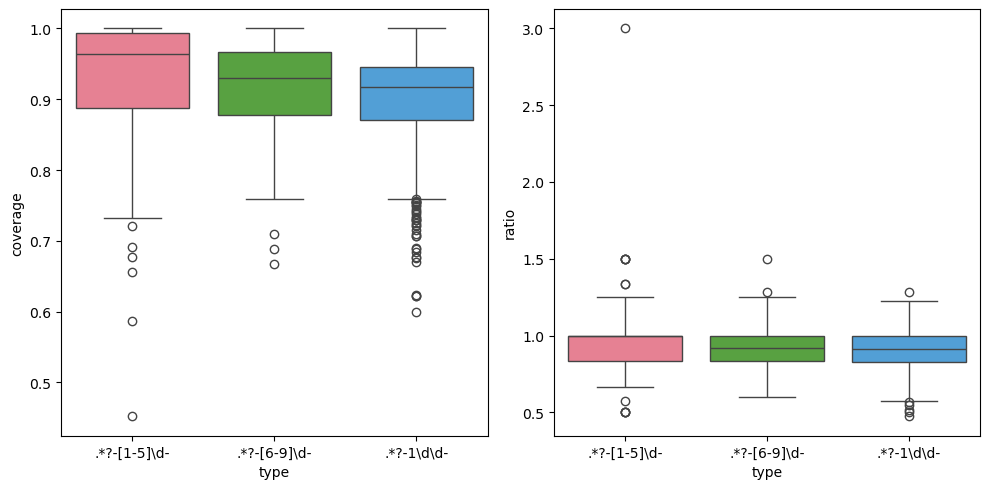

,name,type,coverage,ratio
0,rand-38-21.pol,.*?-[1-5]\d-,0.969698,0.857143
1,rand-12-6.pol,.*?-[1-5]\d-,0.821429,1.000000
2,rand-54-33.pol,.*?-[1-5]\d-,0.967550,1.000000
3,rand-48-34.pol,.*?-[1-5]\d-,0.789970,1.000000
4,rand-52-45.pol,.*?-[1-5]\d-,0.816159,1.000000
...,...,...,...,...
1216,rand-176-165.pol,.*?-1\d\d-,0.954870,1.120000
1217,rand-172-140.pol,.*?-1\d\d-,0.833784,0.840000
1218,rand-106-55.pol,.*?-1\d\d-,0.955671,0.941176
1219,rand-176-2.pol,.*?-1\d\d-,0.867084,0.875000


In [16]:
evaluator.boxplot(testbed_1)

## Multiple Pointer Network Approach


AGMNet consists of $k$ pointer encoder-decoder networks. It encodes polygon of $n$ vertices and decodes $k$ sets of pointers as feasible solutions to the art gallery problem. Another neural net, namely, `CovNet` approximates the coverage of the polygon. The best solution is given according tu `Covnet` best value. 

In [17]:
import torch

# model evaluation
from evaluate import AGMNetSearch
from evaluate import vis_predict

# define parts of architecture
from covnet  import CovNet, Encoder, Aggregator

# demonstrating examples
from demo    import show, polygon_demo3



Reading model from the file.

In [23]:

# AGMNet model
agmnet_model = torch.load('../models/ag_clusters_numsols-3_ne-100_bs-64_hs-256_tfr-0.5_wd-1e-05_lr-0.001_bidirectional_normalized.pt' )
# CovNet model
covnet_model = torch.load(f'../models/covnet.pt')

# AGMNet solver
agmnet_solver = AGMNetSearch(agmnet_model, covnet_model)  # or AGMNetSearch()

/tmp/ipykernel_303608/2200349198.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  agmnet_model = torch.load('../models/ag_clusters_numsols-3_ne-100_bs-64_hs-256_tfr-0.5_w

### Evaluation  

To evaluate our model we use the following metrics: 
  * **coverage** as a ratio of total area of polygon covered with predicted guards
  * **ratio** of number of guards and OPT solution. 



#### Example

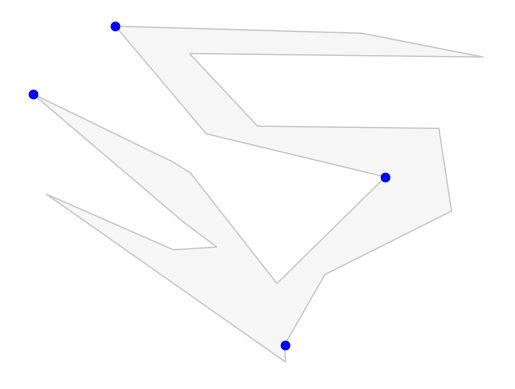

 * Optimal solution size:     4


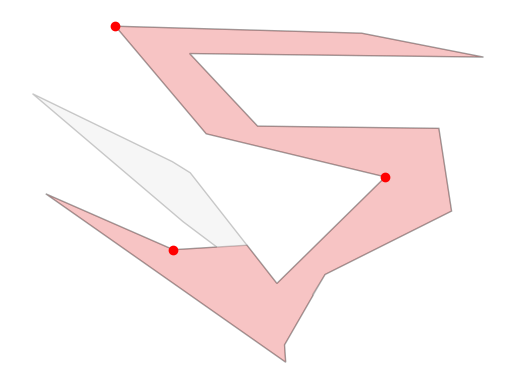

 * Predicted solution size:     3
 * PtrMNet coverage:     0.85407497,      ratio=pred/opt: 0.75000000


Other solutions


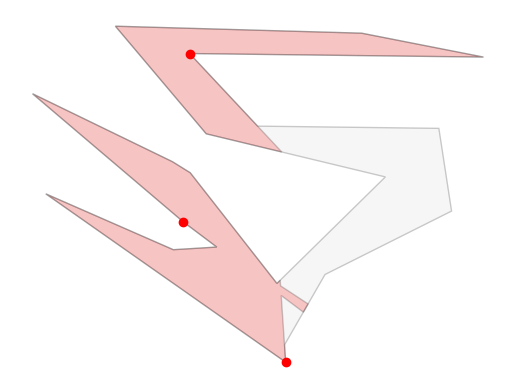

 * Predicted solution size:     3
 * PtrMNet coverage:     0.64574055,      ratio=pred/opt: 0.75000000


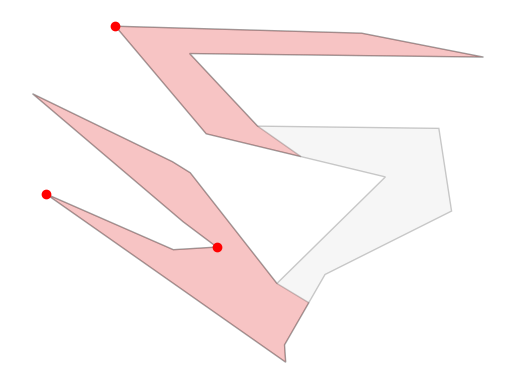

 * Predicted solution size:     3
 * PtrMNet coverage:     0.66237851,      ratio=pred/opt: 0.75000000


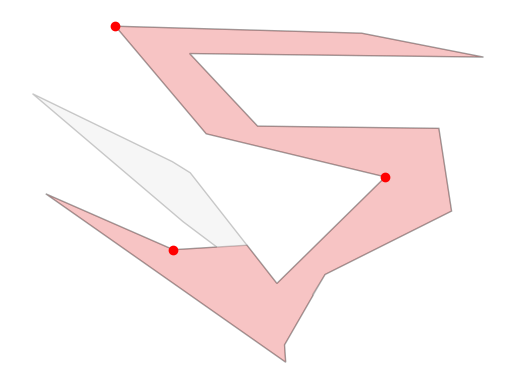

 * Predicted solution size:     3
 * PtrMNet coverage:     0.85407497,      ratio=pred/opt: 0.75000000


In [26]:
# optimal and neural solver
sol_opt    = opt_solver.predict(instance)
sol_agmnet  = agmnet_solver.predict(instance,beam_width=4)


# show only opt solution
poly, region, predicted, opt, coverage = polygon_demo3(sample,sol_opt)
show(poly, region, None, opt, coverage)

# show predicted solution
poly, region, predicted, opt, coverage = polygon_demo3(sample,sol_agmnet)
show(poly, region, predicted, opt, coverage)

# show other solutions
sols = vis_predict(agmnet_model,sample)
# other solutions
print('\n\nOther solutions')
for sol in sols:    
    poly, region, predicted, opt, coverage = polygon_demo3(sample,sol)
    show(poly,region,predicted,opt,coverage)


#### Testbeds

In [21]:
results = {}
dataset_dir = '../dataset/AG/development/test'


testbed_1 = { 
    'name' : 'results_1', 
    'dataset dir' : dataset_dir,
    'regex' : [
         '.*?-[1-5]\d-', # 1-5 tens size
         '.*?-[6-9]\d-', # 6-9 tens sizes,
         '.*?-1\d\d-', # 100s size  
    ] 
}

testbed_2 = { 
    'name' : 'results_2', 
    'dataset dir' : dataset_dir,
    'regex' : [
         '.*?-2\d\d-', # 200s
         '.*?-3\d\d-', # 300s
         '.*?-4\d\d-', # 400s  
        '.*?-5\d\d-', # 500s  
    ] 
}



In [19]:
# evaluation
evaluator = Evaluator(agmnet_solver, dataset_dir)

In [20]:
evaluator.stats(testbed_1)



Pattern 1/3:
Processing rand-32-3.pol                                
Pattern 2/3:
Processing rand-92-19.pol                               
Pattern 3/3:


,counts,mean coverage,std coverage,mean ratio,std ratio
.*?-[1-5]\d-,149,0.922266,0.086040,0.980050,0.188839
.*?-[6-9]\d-,219,0.907773,0.072508,0.873702,0.118026
.*?-1\d\d-,853,0.844587,0.079678,0.753397,0.119376


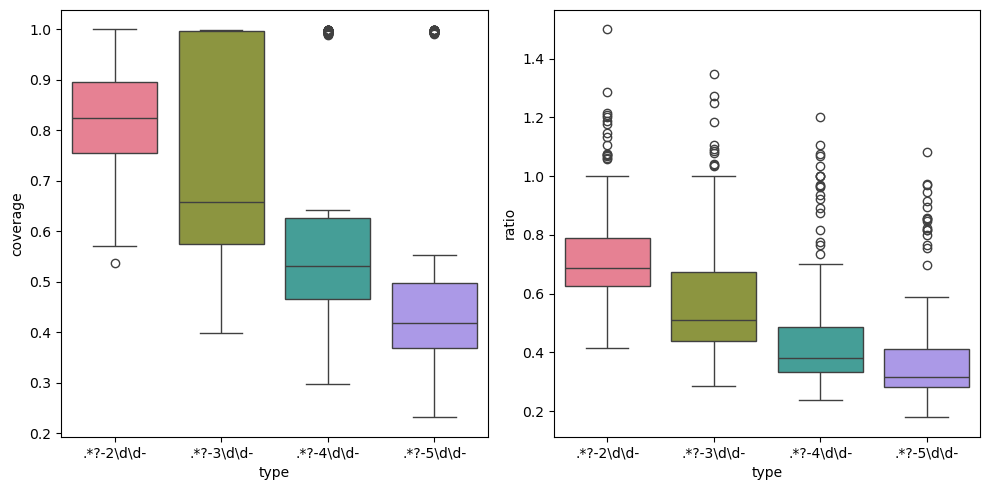

,name,type,coverage,ratio
0,random-200-10.pol,.*?-2\d\d-,0.814863,0.718750
1,randvon-200-5.pol,.*?-2\d\d-,0.993964,0.437500
2,rand-200-197.pol,.*?-2\d\d-,0.837896,0.687500
3,rand-200-117.pol,.*?-2\d\d-,0.802091,0.571429
4,rand-250-14.pol,.*?-2\d\d-,0.654635,0.452381
...,...,...,...,...
879,randsimple-500-27.pol,.*?-5\d\d-,0.394293,0.357143
880,randvon-500-7.pol,.*?-5\d\d-,0.998434,0.756757
881,randsimple-500-26.pol,.*?-5\d\d-,0.369749,0.319444
882,randvon-500-5.pol,.*?-5\d\d-,0.994787,0.575758


In [21]:
evaluator.boxplot(testbed_2)

## Ablation study

Several questions are needed to be answered to justify our architecture:
 1. *Why do we need Pointer Network architecture?*

     > ANSWER: It is hard to implement hard contraints in neural network models. We consider Vertex guards on Art Gallery problem which can be modeled with pointers.

 2. *What is the purpose of multiple encoders-decoders?*

     > ANSWER: Art Gallery problems doesn't have unique solutions. We tried to find different coding of solution so we can infer which solution is the best

 3. *Why do you need to use `CovNet`?*
 
     > ANSWER: `Covnet` as a regression model tries to evaluate coverage of polygon given the solution. The purpose of this is to answer can we encode such geoemtric information in NN? If yes, than our model during the inference doesn't need any geometric information.

4. *Why use only 5 solution clusters?*
    > ANSWER: It was arbitrary, but any larger number of solution clusters will make our model more architecturally complex.

# Data for the paper

In [31]:
# convert to pandas
import pandas as pd


df = pd.read_json('results/results_2.json')
print(df.to_latex(float_format="%.2f"))


\begin{tabular}{lrrrrr}
\toprule
 & counts & mean coverage & std coverage & mean ratio & std ratio \\
\midrule
.*?-[1-5]\d- & 149 & 0.92 & 0.09 & 0.98 & 0.19 \\
.*?-[6-9]\d- & 219 & 0.91 & 0.07 & 0.87 & 0.12 \\
.*?-1\d\d- & 853 & 0.84 & 0.08 & 0.75 & 0.12 \\
.*?-2\d\d- & 373 & 0.83 & 0.11 & 0.72 & 0.15 \\
.*?-3\d\d- & 202 & 0.73 & 0.19 & 0.58 & 0.21 \\
.*?-4\d\d- & 180 & 0.61 & 0.22 & 0.45 & 0.20 \\
.*?-5\d\d- & 129 & 0.53 & 0.26 & 0.40 & 0.20 \\
\bottomrule
\end{tabular}

